<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

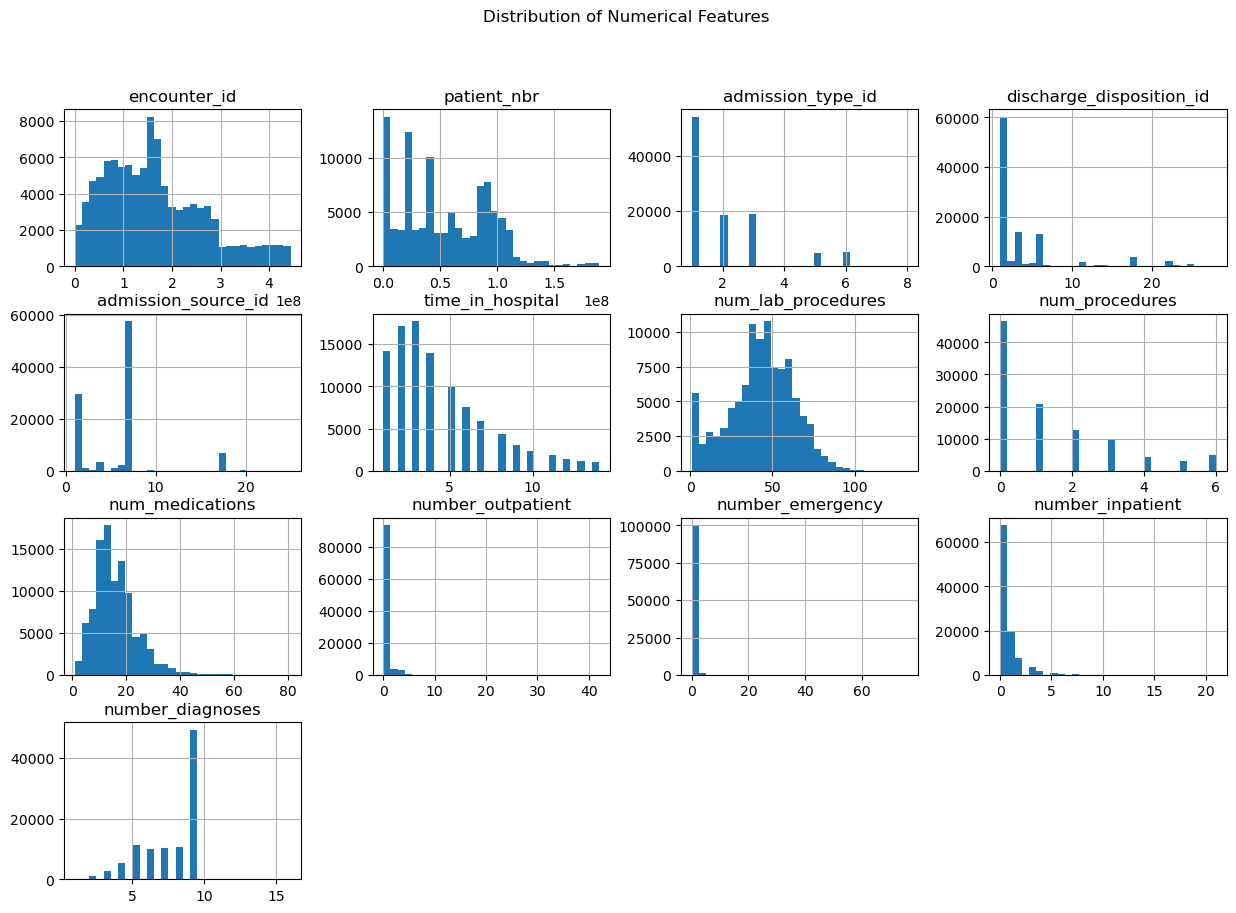

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r'C:\Users\orozc\OneDrive\Documents\GitHub\CAP_3764_2025_Fall_Team_3\data\Diabetes 130 US Hospitals 1999-2008\diabetic_data.csv')
ids = pd.read_csv(r'C:\Users\orozc\OneDrive\Documents\GitHub\CAP_3764_2025_Fall_Team_3\data\Diabetes 130 US Hospitals 1999-2008\IDS_mapping.csv')

# Initial Data Exploration
print(df.info())
print(df.shape)
print(df.head())

#Summary Statistics (Numerical Variables)

#Descriptive statistics for numerical columns(count, mean, std, min, quartiles, max)
num_summary = df.describe()
print(num_summary)

#Calculate Skewness
print(df.skew(numeric_only=True))

# Histograms for numeric columns
df.hist(figsize=(15, 10), bins=30) #makes figure larger and sets number of bins(how many intervals your data range is split into)
plt.suptitle("Distribution of Numerical Features") #Title
plt.show() #Shows the plot



--- race ---
race
Caucasian          0.747784
AfricanAmerican    0.188766
?                  0.022336
Hispanic           0.020017
Other              0.014799
Asian              0.006299
Name: proportion, dtype: float64

--- gender ---
gender
Female             0.537586
Male               0.462384
Unknown/Invalid    0.000029
Name: proportion, dtype: float64

--- age ---
age
[70-80)     0.256156
[60-70)     0.220928
[50-60)     0.169565
[80-90)     0.168986
[40-50)     0.095169
[30-40)     0.037095
[90-100)    0.027445
[20-30)     0.016282
[10-20)     0.006790
[0-10)      0.001582
Name: proportion, dtype: float64

--- weight ---
weight
?            0.968585
[75-100)     0.013128
[50-75)      0.008814
[100-125)    0.006142
[125-150)    0.001425
[25-50)      0.000953
[0-25)       0.000472
[150-175)    0.000344
[175-200)    0.000108
>200         0.000029
Name: proportion, dtype: float64

--- payer_code ---
payer_code
?     0.395574
MC    0.318761
HM    0.061651
SP    0.049201
BC    0.04574

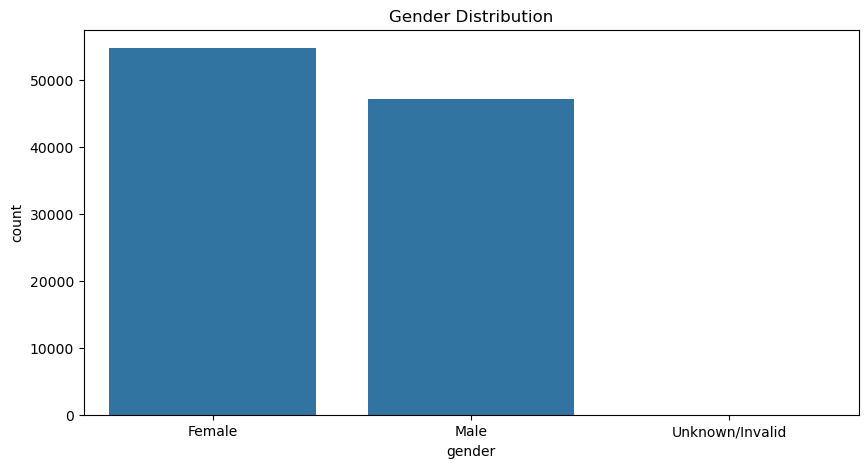

In [ ]:

#Categorical Variables
#Selects only columns that have "object" dtype (usually strings/categorical data)
cat_cols = df.select_dtypes(include="object").columns
#Loops through each categorical column and prints value counts (frequency of each category)
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).head(10))  # top 10 categories

# Example countplot
plt.figure(figsize=(10,5))
sns.countplot(x="gender", data=df, order=df["gender"].value_counts().index)
plt.title("Gender Distribution")
plt.show()


In [ ]:

#Summary Tables

# Group numerical summary by a categorical variable
summary_by_race = df.groupby("race").describe()
print(summary_by_race)


                encounter_id                                         \
                       count          mean           std        min   
race                                                                  
?                     2273.0  1.728853e+08  1.123099e+08   148530.0   
AfricanAmerican      19210.0  1.451321e+08  9.273159e+07    28236.0   
Asian                  641.0  2.041567e+08  1.197483e+08  2655870.0   
Caucasian            76099.0  1.688394e+08  1.030294e+08    12522.0   
Hispanic              2037.0  1.748444e+08  1.159323e+08  2791716.0   
Other                 1506.0  1.961646e+08  1.221276e+08   221634.0   

                                                                     \
                         25%          50%          75%          max   
race                                                                  
?                 94165566.0  110749296.0  254566272.0  443728472.0   
AfricanAmerican   77316387.0  135075513.0  178376416.5  443847782.0   
Asian

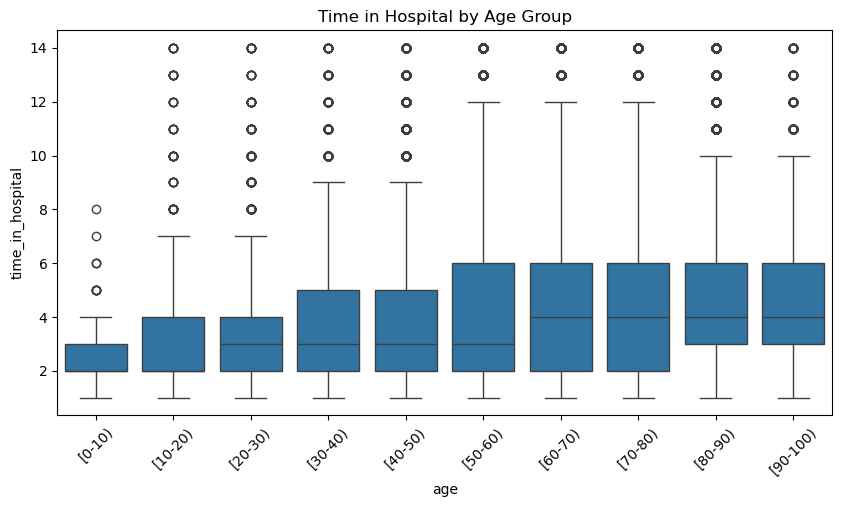

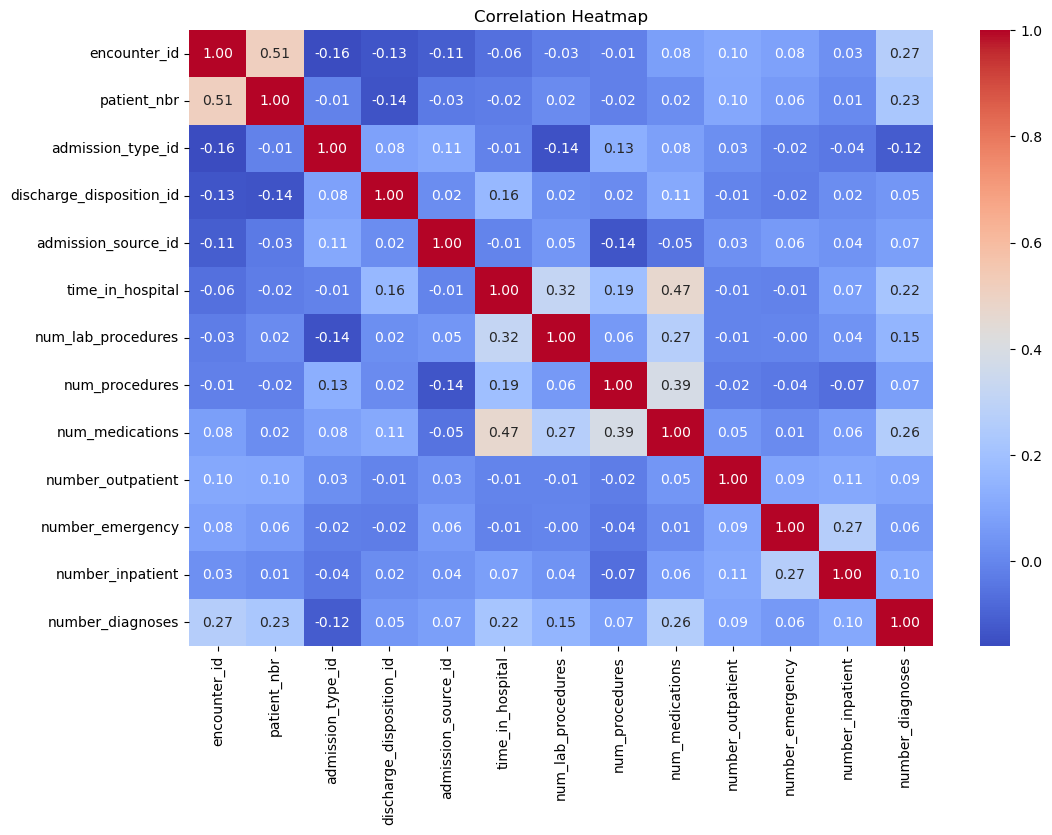

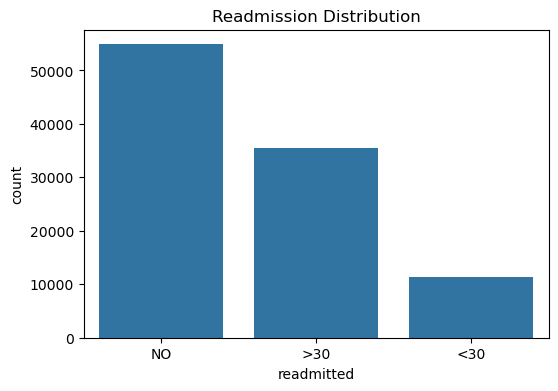

In [9]:

#Visualizations

# Boxplot of age vs time_in_hospital (example numeric vs numeric)
plt.figure(figsize=(10,5))
sns.boxplot(x="age", y="time_in_hospital", data=df)
plt.title("Time in Hospital by Age Group")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap for numeric features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Bar plot for readmitted (categorical target example)
plt.figure(figsize=(6,4))
sns.countplot(x="readmitted", data=df, order=df["readmitted"].value_counts().index)
plt.title("Readmission Distribution")
plt.show()  